In [27]:
import numpy as np
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
import joblib


In [28]:
for root, dirs, files in os.walk("C:/Users/user/Downloads/energy+efficiency"):
    for file in files:
        print(file)
        
print(sys.executable)

c:\Users\user\AppData\Local\Programs\Python\Python313\python.exe


In [29]:
df = pd.read_excel(r"C:\Users\user\Downloads\energy efficiency\Energy\ENB2012_data.xlsx")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [30]:
df.columns

df.rename(columns={
    'X1':'Relative_Compactness',
    'X2':'Surface_Area',
    'X3':'Wall_Area',
    'X4':'Roof_Area',
    'X5':'Overall_Height',
    'X6':'Orientation',
    'X7':'Glazing_Area',
    'X8':'Glazing_Area_Distribution',
    'Y1':'Heating_Load',
    'Y2':'Cooling_Load'
}, inplace=True)

In [31]:
df

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [32]:
# Define project objective
target_variables = ["Heating Load", "Cooling Load"]

print("Project Goal:")
print("Predict Heating Load and Cooling Load of buildings.")

Project Goal:
Predict Heating Load and Cooling Load of buildings.


# IMPORT DATA


In [33]:
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


# Exploratory Data Analysis (EDA)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [35]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [36]:
for i in df.columns:
    if df[i].dtype=="float":
        print(df[i].value_counts())
        print("THE COLUMNS",df[i])
        print("\n")

Relative_Compactness
0.98    64
0.90    64
0.86    64
0.82    64
0.79    64
0.76    64
0.74    64
0.71    64
0.69    64
0.66    64
0.64    64
0.62    64
Name: count, dtype: int64
THE COLUMNS 0      0.98
1      0.98
2      0.98
3      0.98
4      0.90
       ... 
763    0.64
764    0.62
765    0.62
766    0.62
767    0.62
Name: Relative_Compactness, Length: 768, dtype: float64


Surface_Area
514.5    64
563.5    64
588.0    64
612.5    64
637.0    64
661.5    64
686.0    64
710.5    64
735.0    64
759.5    64
784.0    64
808.5    64
Name: count, dtype: int64
THE COLUMNS 0      514.5
1      514.5
2      514.5
3      514.5
4      563.5
       ...  
763    784.0
764    808.5
765    808.5
766    808.5
767    808.5
Name: Surface_Area, Length: 768, dtype: float64


Wall_Area
294.0    192
318.5    192
343.0    128
416.5     64
245.0     64
269.5     64
367.5     64
Name: count, dtype: int64
THE COLUMNS 0      294.0
1      294.0
2      294.0
3      294.0
4      318.5
       ...  
763    343.0
7

In [37]:
df["Relative_Compactness"].value_counts()


Relative_Compactness
0.98    64
0.90    64
0.86    64
0.82    64
0.79    64
0.76    64
0.74    64
0.71    64
0.69    64
0.66    64
0.64    64
0.62    64
Name: count, dtype: int64

In [38]:
df["Surface_Area"].value_counts()

Surface_Area
514.5    64
563.5    64
588.0    64
612.5    64
637.0    64
661.5    64
686.0    64
710.5    64
735.0    64
759.5    64
784.0    64
808.5    64
Name: count, dtype: int64

In [39]:
df["Wall_Area"].value_counts()

Wall_Area
294.0    192
318.5    192
343.0    128
416.5     64
245.0     64
269.5     64
367.5     64
Name: count, dtype: int64

In [40]:
df["Roof_Area"].value_counts()

Roof_Area
220.50    384
147.00    192
122.50    128
110.25     64
Name: count, dtype: int64

In [41]:
df["Overall_Height"].value_counts()

Overall_Height
7.0    384
3.5    384
Name: count, dtype: int64

In [42]:
df["Orientation"].value_counts()

Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64

In [43]:
df["Glazing_Area"].value_counts()

Glazing_Area
0.10    240
0.25    240
0.40    240
0.00     48
Name: count, dtype: int64

In [44]:
df["Glazing_Area_Distribution"].value_counts()

Glazing_Area_Distribution
1    144
2    144
4    144
3    144
5    144
0     48
Name: count, dtype: int64

In [45]:
df["Heating_Load"].value_counts()

Heating_Load
15.16    6
13.00    5
15.55    4
15.23    4
28.15    4
        ..
28.52    1
15.98    1
16.95    1
17.41    1
17.05    1
Name: count, Length: 587, dtype: int64

In [46]:
df["Cooling_Load"].value_counts()

Cooling_Load
29.79    4
17.20    4
14.27    4
21.33    4
14.28    4
        ..
38.56    1
33.84    1
29.56    1
29.93    1
35.71    1
Name: count, Length: 636, dtype: int64

In [47]:
for column in df.columns:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())


Unique values in Relative_Compactness:
[0.98 0.9  0.86 0.82 0.79 0.76 0.74 0.71 0.69 0.66 0.64 0.62]

Unique values in Surface_Area:
[514.5 563.5 588.  612.5 637.  661.5 686.  710.5 735.  759.5 784.  808.5]

Unique values in Wall_Area:
[294.  318.5 343.  416.5 245.  269.5 367.5]

Unique values in Roof_Area:
[110.25 122.5  147.   220.5 ]

Unique values in Overall_Height:
[7.  3.5]

Unique values in Orientation:
[2 3 4 5]

Unique values in Glazing_Area:
[0.   0.1  0.25 0.4 ]

Unique values in Glazing_Area_Distribution:
[0 1 2 3 4 5]

Unique values in Heating_Load:
[15.55  20.84  21.46  20.71  19.68  19.5   19.95  19.34  18.31  17.05
 17.41  16.95  15.98  28.52  29.9   29.63  28.75  24.77  23.93   6.07
  6.05   6.01   6.04   6.37   6.4    6.366  6.85   6.79   6.77   6.81
  7.18   7.1   10.85  10.54  10.77  10.56   8.6    8.49   8.45   8.5
 24.58  24.63  24.59  29.03  29.87  29.14  28.09  26.28  26.91  26.37
 25.27  23.53  24.03  23.54  22.58  35.56  37.12  36.9   35.94  32.96
 32.12  32.

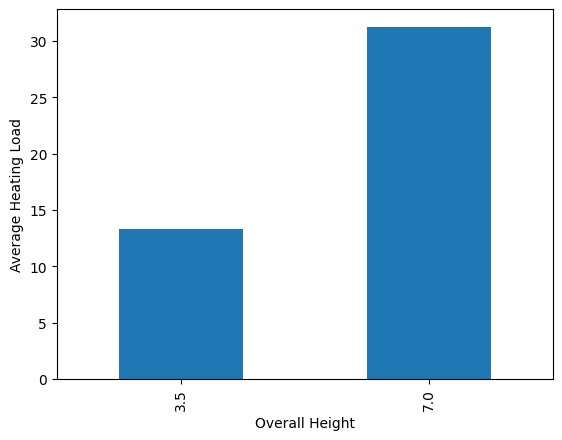

In [49]:
# Average heating load by overall height
result = df.groupby('Overall_Height')['Heating_Load'].mean()

result.plot(kind="bar")
plt.xlabel("Overall Height")
plt.ylabel("Average Heating Load")
plt.show()

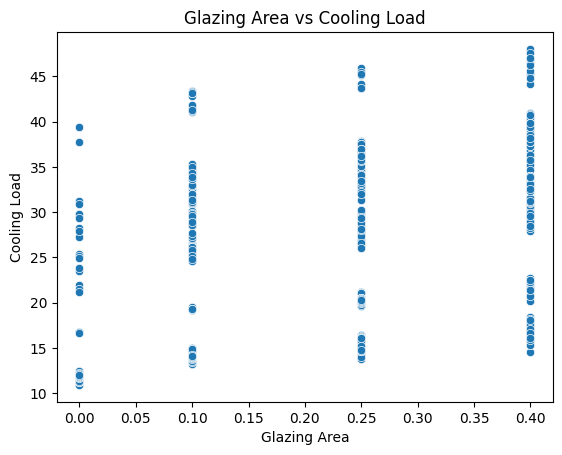

In [50]:
#Analyze whether larger window areas increase cooling requirements.

sns.scatterplot(x=df['Glazing_Area'], y=df['Cooling_Load'])

plt.xlabel('Glazing Area')
plt.ylabel('Cooling Load')
plt.title('Glazing Area vs Cooling Load')

plt.show()

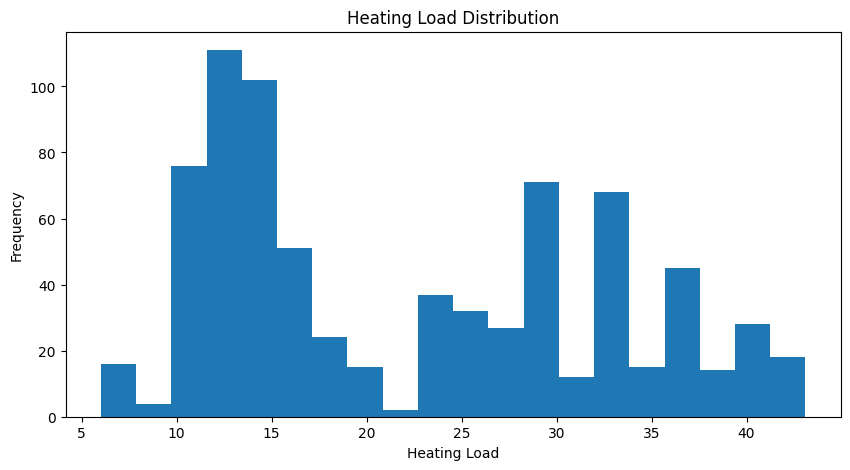

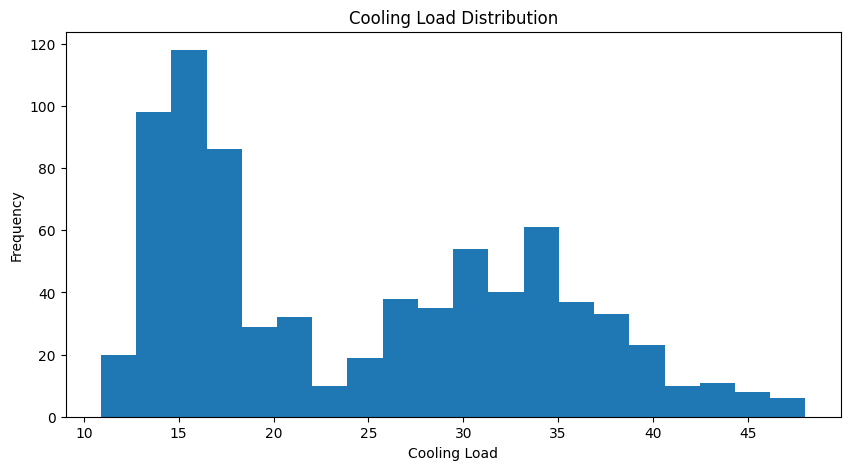

In [51]:
#What is the distribution of Heating Load and Cooling Load?

plt.figure(figsize=(10,5))

plt.hist(df['Heating_Load'], bins=20)

plt.title('Heating Load Distribution')
plt.xlabel('Heating Load')
plt.ylabel('Frequency')

plt.show()

plt.figure(figsize=(10,5))

plt.hist(df['Cooling_Load'], bins=20)

plt.title('Cooling Load Distribution')
plt.xlabel('Cooling Load')
plt.ylabel('Frequency')

plt.show()

In [52]:
#Which feature has the strongest correlation with Heating Load?

corr = df.corr()

heating_corr = corr['Heating_Load'].sort_values(ascending=False)

print(heating_corr)

Heating_Load                 1.000000
Cooling_Load                 0.975862
Overall_Height               0.889430
Relative_Compactness         0.622272
Wall_Area                    0.455671
Glazing_Area                 0.269842
Glazing_Area_Distribution    0.087368
Orientation                 -0.002587
Surface_Area                -0.658120
Roof_Area                   -0.861828
Name: Heating_Load, dtype: float64


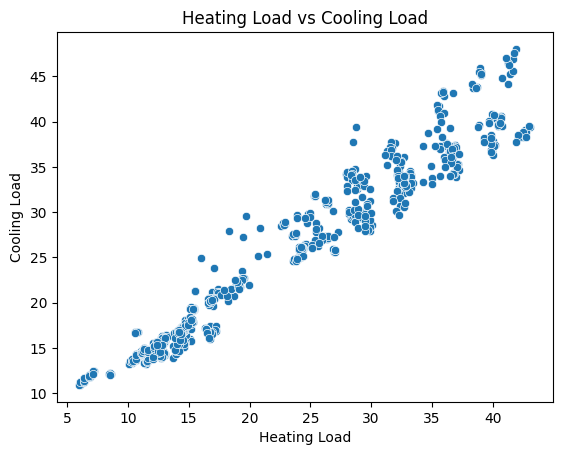

Correlation = 0.9758617391437691


In [53]:
#ip between Heating Load and Cooling Load?

sns.scatterplot(x=df['Heating_Load'], y=df['Cooling_Load'])

plt.xlabel('Heating Load')
plt.ylabel('Cooling Load')
plt.title('Heating Load vs Cooling Load')

plt.show()

print("Correlation =", df['Heating_Load'].corr(df['Cooling_Load']))